In [28]:
!pip install vaderSentiment yfinance -q

import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

ARCTIC_SHIFT_URL = 'https://arctic-shift.photon-reddit.com/api/posts/search'

def scrape_subreddit_monthly(subreddit_name, ticker, posts_per_month=100):
    # I'm scraping one month at a time to keep the time series clean. I tried
    # paginating to get more posts per month, but I kept losing data.
    posts = []
    months = pd.date_range(start='2022-01-01', end='2024-06-01', freq='MS')

    for month_start in months:
        month_end = month_start + pd.DateOffset(months=1)
        params = {
            'subreddit': subreddit_name,
            'limit': min(posts_per_month, 100),
            'after': month_start.strftime('%Y-%m-%dT%H:%M:%S'),
            'before': month_end.strftime('%Y-%m-%dT%H:%M:%S'),
            'sort': 'asc'
        }
        r = requests.get(ARCTIC_SHIFT_URL, params=params)
        if r.status_code != 200:
            print(f'Error {r.status_code} for {month_start.strftime("%Y-%m")}')
            continue
        data = r.json().get('data', [])
        for post in data:
            text = post.get('selftext', '')
            if text in ['[deleted]', '[removed]']:
                text = ''
            posts.append({
                'ticker': ticker,
                'title': post.get('title', ''),
                'text': text,
                'score': post.get('score', 0),
                'num_comments': post.get('num_comments', 0),
                'timestamp': datetime.utcfromtimestamp(post.get('created_utc', 0)),
                'full_text': post.get('title', '') + ' ' + text
            })
        print(f'r/{subreddit_name} {month_start.strftime("%Y-%m")}: {len(data)} posts')
        time.sleep(0.5)

    df = pd.DataFrame(posts)
    if len(df) == 0:
        df = pd.DataFrame(columns=['ticker','title','text','score',
                                  'num_comments','timestamp','full_text','date'])
    else:
        df['date'] = pd.to_datetime(df['timestamp']).dt.date
    print(f'Total: {len(df)} posts from r/{subreddit_name}\n')
    return df

# ***COMPANY SELECTION***
# I started this analysis looking at CMG, SBUX, NKE, but ended up dropping
# and replacing SBUX and NKE.

# The r/starbucks thread is full of employees talking about working conditions
# and unionization, rather than customer experience sentiment. The model
# actually confirmed this, as SBUX had high positive sentiment before misses,
# which is the opposite of what should happen if the signal worked.
#
# In the r/Nike thread, there were a bunch of posts where people were reselling
# things or talking about new releases. It wasn't really representative of
# Nike's broader consumer base. There was also only one earnings miss in the
# whole span of the data, so I couldn't really train the model with that.
#
# After removing those two companies, I added a few other restaurant chains
# where the subreddits were more clearly customer-focused (people complaining
# about portion sizes, wait times, new menu items, etc.), as these are better
# indicators of sales.

universe = [
    ('chipotle', 'CMG'),
    ('McDonalds', 'MCD'),
    ('Dominos', 'DPZ'),
    ('Wendys', 'WEN'),
    ('ShakeShack', 'SHAK')
]

for sub, ticker in universe:
    pm = 50 if ticker == 'SHAK' else 100
    df = scrape_subreddit_monthly(sub, ticker, posts_per_month=pm)
    df.to_csv(f'/content/{ticker}_posts.csv', index=False)
    print(f'Saved {ticker} — {len(df)} posts')

all_posts = pd.concat([
    pd.read_csv(f'/content/{ticker}_posts.csv')
    for _, ticker in universe
], ignore_index=True)

print(f'\nTotal posts: {len(all_posts)}')
print(all_posts['ticker'].value_counts())

/tmp/ipykernel_2928/3896413213.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  'timestamp': datetime.utcfromtimestamp(post.get('created_utc', 0)),


r/chipotle 2022-01: 100 posts
r/chipotle 2022-02: 100 posts
r/chipotle 2022-03: 100 posts
r/chipotle 2022-04: 100 posts
r/chipotle 2022-05: 100 posts
r/chipotle 2022-06: 100 posts
r/chipotle 2022-07: 100 posts
r/chipotle 2022-08: 100 posts
r/chipotle 2022-09: 100 posts
r/chipotle 2022-10: 100 posts
r/chipotle 2022-11: 100 posts
r/chipotle 2022-12: 100 posts
r/chipotle 2023-01: 100 posts
r/chipotle 2023-02: 100 posts
r/chipotle 2023-03: 100 posts
r/chipotle 2023-04: 100 posts
r/chipotle 2023-05: 100 posts
r/chipotle 2023-06: 100 posts
r/chipotle 2023-07: 100 posts
r/chipotle 2023-08: 100 posts
r/chipotle 2023-09: 100 posts
r/chipotle 2023-10: 100 posts
r/chipotle 2023-11: 100 posts
r/chipotle 2023-12: 100 posts
r/chipotle 2024-01: 100 posts
r/chipotle 2024-02: 100 posts
r/chipotle 2024-03: 100 posts
r/chipotle 2024-04: 100 posts
r/chipotle 2024-05: 100 posts
r/chipotle 2024-06: 100 posts
Total: 3000 posts from r/chipotle

Saved CMG — 3000 posts


/tmp/ipykernel_2928/3896413213.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  'timestamp': datetime.utcfromtimestamp(post.get('created_utc', 0)),


r/McDonalds 2022-01: 100 posts
r/McDonalds 2022-02: 85 posts
r/McDonalds 2022-03: 100 posts
r/McDonalds 2022-04: 68 posts
r/McDonalds 2022-05: 81 posts
r/McDonalds 2022-06: 80 posts
r/McDonalds 2022-07: 92 posts
r/McDonalds 2022-08: 82 posts
r/McDonalds 2022-09: 75 posts
r/McDonalds 2022-10: 100 posts
r/McDonalds 2022-11: 98 posts
r/McDonalds 2022-12: 100 posts
r/McDonalds 2023-01: 100 posts
r/McDonalds 2023-02: 83 posts
r/McDonalds 2023-03: 99 posts
r/McDonalds 2023-04: 100 posts
r/McDonalds 2023-05: 100 posts
r/McDonalds 2023-06: 100 posts
r/McDonalds 2023-07: 100 posts
r/McDonalds 2023-08: 100 posts
r/McDonalds 2023-09: 100 posts
r/McDonalds 2023-10: 100 posts
r/McDonalds 2023-11: 100 posts
r/McDonalds 2023-12: 100 posts
r/McDonalds 2024-01: 100 posts
r/McDonalds 2024-02: 100 posts
r/McDonalds 2024-03: 100 posts
r/McDonalds 2024-04: 100 posts
r/McDonalds 2024-05: 100 posts
r/McDonalds 2024-06: 100 posts
Total: 2843 posts from r/McDonalds

Saved MCD — 2843 posts


/tmp/ipykernel_2928/3896413213.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  'timestamp': datetime.utcfromtimestamp(post.get('created_utc', 0)),


r/Dominos 2022-01: 100 posts
r/Dominos 2022-02: 100 posts
r/Dominos 2022-03: 100 posts
r/Dominos 2022-04: 100 posts
r/Dominos 2022-05: 100 posts
r/Dominos 2022-06: 100 posts
r/Dominos 2022-07: 100 posts
r/Dominos 2022-08: 100 posts
r/Dominos 2022-09: 100 posts
r/Dominos 2022-10: 100 posts
r/Dominos 2022-11: 100 posts
r/Dominos 2022-12: 100 posts
r/Dominos 2023-01: 100 posts
r/Dominos 2023-02: 100 posts
r/Dominos 2023-03: 100 posts
r/Dominos 2023-04: 100 posts
r/Dominos 2023-05: 100 posts
r/Dominos 2023-06: 100 posts
r/Dominos 2023-07: 100 posts
r/Dominos 2023-08: 100 posts
r/Dominos 2023-09: 100 posts
r/Dominos 2023-10: 100 posts
r/Dominos 2023-11: 100 posts
r/Dominos 2023-12: 100 posts
r/Dominos 2024-01: 100 posts
r/Dominos 2024-02: 100 posts
r/Dominos 2024-03: 100 posts
r/Dominos 2024-04: 100 posts
r/Dominos 2024-05: 100 posts
r/Dominos 2024-06: 100 posts
Total: 3000 posts from r/Dominos

Saved DPZ — 3000 posts


/tmp/ipykernel_2928/3896413213.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  'timestamp': datetime.utcfromtimestamp(post.get('created_utc', 0)),


r/Wendys 2022-01: 100 posts
r/Wendys 2022-02: 100 posts
r/Wendys 2022-03: 100 posts
r/Wendys 2022-04: 100 posts
r/Wendys 2022-05: 100 posts
r/Wendys 2022-06: 100 posts
r/Wendys 2022-07: 100 posts
r/Wendys 2022-08: 100 posts
r/Wendys 2022-09: 100 posts
r/Wendys 2022-10: 100 posts
r/Wendys 2022-11: 100 posts
r/Wendys 2022-12: 100 posts
r/Wendys 2023-01: 100 posts
r/Wendys 2023-02: 100 posts
r/Wendys 2023-03: 100 posts
r/Wendys 2023-04: 100 posts
r/Wendys 2023-05: 100 posts
r/Wendys 2023-06: 100 posts
r/Wendys 2023-07: 100 posts
r/Wendys 2023-08: 100 posts
r/Wendys 2023-09: 100 posts
r/Wendys 2023-10: 100 posts
r/Wendys 2023-11: 100 posts
r/Wendys 2023-12: 100 posts
r/Wendys 2024-01: 100 posts
r/Wendys 2024-02: 100 posts
r/Wendys 2024-03: 100 posts
r/Wendys 2024-04: 100 posts
r/Wendys 2024-05: 100 posts
r/Wendys 2024-06: 100 posts
Total: 3000 posts from r/Wendys

Saved WEN — 3000 posts


/tmp/ipykernel_2928/3896413213.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  'timestamp': datetime.utcfromtimestamp(post.get('created_utc', 0)),


r/ShakeShack 2022-01: 7 posts
r/ShakeShack 2022-02: 8 posts
r/ShakeShack 2022-03: 7 posts
r/ShakeShack 2022-04: 6 posts
r/ShakeShack 2022-05: 7 posts
r/ShakeShack 2022-06: 5 posts
r/ShakeShack 2022-07: 8 posts
r/ShakeShack 2022-08: 5 posts
r/ShakeShack 2022-09: 10 posts
r/ShakeShack 2022-10: 3 posts
r/ShakeShack 2022-11: 2 posts
r/ShakeShack 2022-12: 8 posts
r/ShakeShack 2023-01: 15 posts
r/ShakeShack 2023-02: 5 posts
r/ShakeShack 2023-03: 2 posts
r/ShakeShack 2023-04: 2 posts
r/ShakeShack 2023-05: 7 posts
r/ShakeShack 2023-06: 5 posts
r/ShakeShack 2023-07: 4 posts
r/ShakeShack 2023-08: 9 posts
r/ShakeShack 2023-09: 4 posts
r/ShakeShack 2023-10: 7 posts
r/ShakeShack 2023-11: 8 posts
r/ShakeShack 2023-12: 8 posts
r/ShakeShack 2024-01: 22 posts
r/ShakeShack 2024-02: 10 posts
r/ShakeShack 2024-03: 11 posts
r/ShakeShack 2024-04: 15 posts
r/ShakeShack 2024-05: 26 posts
r/ShakeShack 2024-06: 13 posts
Total: 249 posts from r/ShakeShack

Saved SHAK — 249 posts

Total posts: 12092
ticker
CMG   

In [29]:
# ***SENTIMENT SCORING***

# I'm using VADER for the sentiment scoring. I tried FinBERT first since it's more
# finance-specific, but it actually made the model less accurate
# for this dataset — likely because Reddit language is very informal, so
# VADER's training on social media text does a better job at discerning the
# sentiment on this data.

analyzer = SentimentIntensityAnalyzer()

def score_sentiment(text):
    if not isinstance(text, str) or text.strip() == '':
        return 0
    return analyzer.polarity_scores(text)['compound']

all_posts['sent_score'] = all_posts['full_text'].apply(score_sentiment)

# I'm weighting the posts by level of engagement, so that posts with a high
# volume of upvotes carry more weight (signal) than those with low engagement.
# I'm also using a log scale so that no single viral post completely dominates
# a weekly average.

all_posts['weighted_sent'] = all_posts['sent_score'] * np.log1p(
    all_posts['score'] + all_posts['num_comments']
)

print('Sentiment scoring done.')

# ***WEEKLY AGGREGATION***

all_posts['date'] = pd.to_datetime(all_posts['date'])

weekly_sent = (
    all_posts
    .groupby(['ticker', pd.Grouper(key='date', freq='W')])
    .agg(
        avg_sent=('sent_score', 'mean'),
        weighted_sent=('weighted_sent', 'sum'),
        post_vol=('sent_score', 'count')
    )
    .reset_index()
)

# I'm using a 4-week rolling average to smooth out noise.
weekly_sent['rolling_sent'] = (
    weekly_sent
    .groupby('ticker')['avg_sent']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# I decided to use z-scores by ticker so that scores are comparable across
# companies, because the threads for each company had varying baseline tones,
# so it wasn't apples to apples. A -1.5 z-score means the same thing for both
# after normalizing.
# I considered min-max scaling first, but z-score felt more appropriate
# because I don't want one extreme data point to become the floor or ceiling
# and distort everything. Z-scoring is more stable for detecting deviations
# from a company's normal baseline.

weekly_sent['sent_zscore'] = (
    weekly_sent
    .groupby('ticker')['rolling_sent']
    .transform(lambda x: (x - x.mean()) / x.std())
)

print('Aggregation and normalization done.')
print(f'Shape: {weekly_sent.shape}')

# ***STOCK PRICES & EARNINGS***

tickers = ['CMG', 'MCD', 'DPZ', 'WEN', 'SHAK']

price_data = yf.download(tickers, start='2022-01-01', end='2024-06-01', auto_adjust=True)['Close']
weekly_returns = price_data.resample('W').last().pct_change()
weekly_returns = weekly_returns.stack().reset_index()
weekly_returns.columns = ['date', 'ticker', 'weekly_return']

print('Stock prices pulled.')

def get_earnings(ticker):
    stock = yf.Ticker(ticker)
    earn = stock.earnings_dates
    if earn is None or len(earn) == 0:
        return pd.DataFrame()
    earn = earn.reset_index()
    earn.columns = [c.lower().replace(' ', '_') for c in earn.columns]
    earn['ticker'] = ticker
    earn['date'] = pd.to_datetime(earn['earnings_date']).dt.tz_localize(None)
    if 'surprise(%)' in earn.columns:
        earn['beat'] = (earn['surprise(%)'] > 0).astype(int)
    return earn[['ticker', 'date', 'beat']].dropna()

earn_df = pd.concat([get_earnings(t) for t in tickers], ignore_index=True)
earn_df = earn_df[
    (earn_df['date'] >= '2022-01-01') &
    (earn_df['date'] <= '2024-06-01')
]

print(f'Earnings events: {len(earn_df)}')
print(earn_df['ticker'].value_counts())

# ***PRE-EARNINGS SENTIMENT WINDOWS***
    # I'm using the average z-scored sentiment in the 30 day window leading up
    # to each earnings release. This is long enough to capture trend, but short
    # enough to remain relevant to the quarter at hand.

def get_pre_earn_sent(ticker, earn_date, sent_df, window_days=30):

    window_start = earn_date - timedelta(days=window_days)

    mask = (
        (sent_df['ticker'] == ticker) &
        (sent_df['date'] >= window_start) &
        (sent_df['date'] < earn_date)
    )

    window = sent_df[mask]

    if len(window) == 0:
        return np.nan

    return window['sent_zscore'].mean()

earn_df['date'] = pd.to_datetime(earn_df['date'])
weekly_sent['date'] = pd.to_datetime(weekly_sent['date'])

earn_df['pre_earn_sent'] = earn_df.apply(
    lambda row: get_pre_earn_sent(
        row['ticker'], row['date'], weekly_sent
    ), axis=1
)

model_df = earn_df.dropna(subset=['pre_earn_sent', 'beat'])

print(f'\nModel dataset: {len(model_df)} earnings events')
print(model_df['ticker'].value_counts())
print(f'Beat rate: {model_df["beat"].mean():.1%}')
print(model_df[['ticker', 'date', 'pre_earn_sent', 'beat']])

# ***LOGISTIC REGRESSION***
# I'm using class_weight='balanced' because 82% of earnings events are beats —
# without it the model just predicts beat every time and learns nothing.
# I think in a trading context, catching misses is even more important than
# just maximizing raw accuracy, so I'm optimizing for recall here.

X = model_df[['pre_earn_sent']]
y = model_df['beat']

model = LogisticRegression(class_weight='balanced')
model.fit(X, y)

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print('\n--- Logistic Regression: Reddit Sentiment → Earnings Beat/Miss ---')
print(f'Cross-validated accuracy: {cv_scores.mean():.1%} (+/- {cv_scores.std():.1%})')
print(f'Baseline (always predict majority): {max(y.mean(), 1-y.mean()):.1%}')
print()
print(classification_report(y, model.predict(X), target_names=['Miss', 'Beat']))

[                       0%                       ]

Sentiment scoring done.
Aggregation and normalization done.
Shape: (414, 7)


[*********************100%***********************]  5 of 5 completed


Stock prices pulled.
Earnings events: 50
ticker
CMG     10
MCD     10
DPZ     10
WEN     10
SHAK    10
Name: count, dtype: int64

Model dataset: 50 earnings events
ticker
CMG     10
MCD     10
DPZ     10
WEN     10
SHAK    10
Name: count, dtype: int64
Beat rate: 82.0%
    ticker                date  pre_earn_sent  beat
8      CMG 2024-04-24 16:00:00       1.323831     1
9      CMG 2024-02-06 16:00:00       0.180096     1
10     CMG 2023-10-26 16:00:00      -0.223170     1
11     CMG 2023-07-26 16:00:00       1.329678     1
12     CMG 2023-04-25 16:00:00       0.347754     1
13     CMG 2023-02-07 16:00:00      -1.074667     0
14     CMG 2022-10-25 16:00:00      -0.417129     1
15     CMG 2022-07-26 16:00:00      -0.071255     1
16     CMG 2022-04-26 16:00:00      -1.730725     1
17     CMG 2022-02-08 16:00:00      -2.190301     1
33     MCD 2024-04-30 07:00:00      -0.591493     0
34     MCD 2024-02-05 07:00:00      -0.086150     1
35     MCD 2023-10-30 07:00:00       1.081774     1
36 

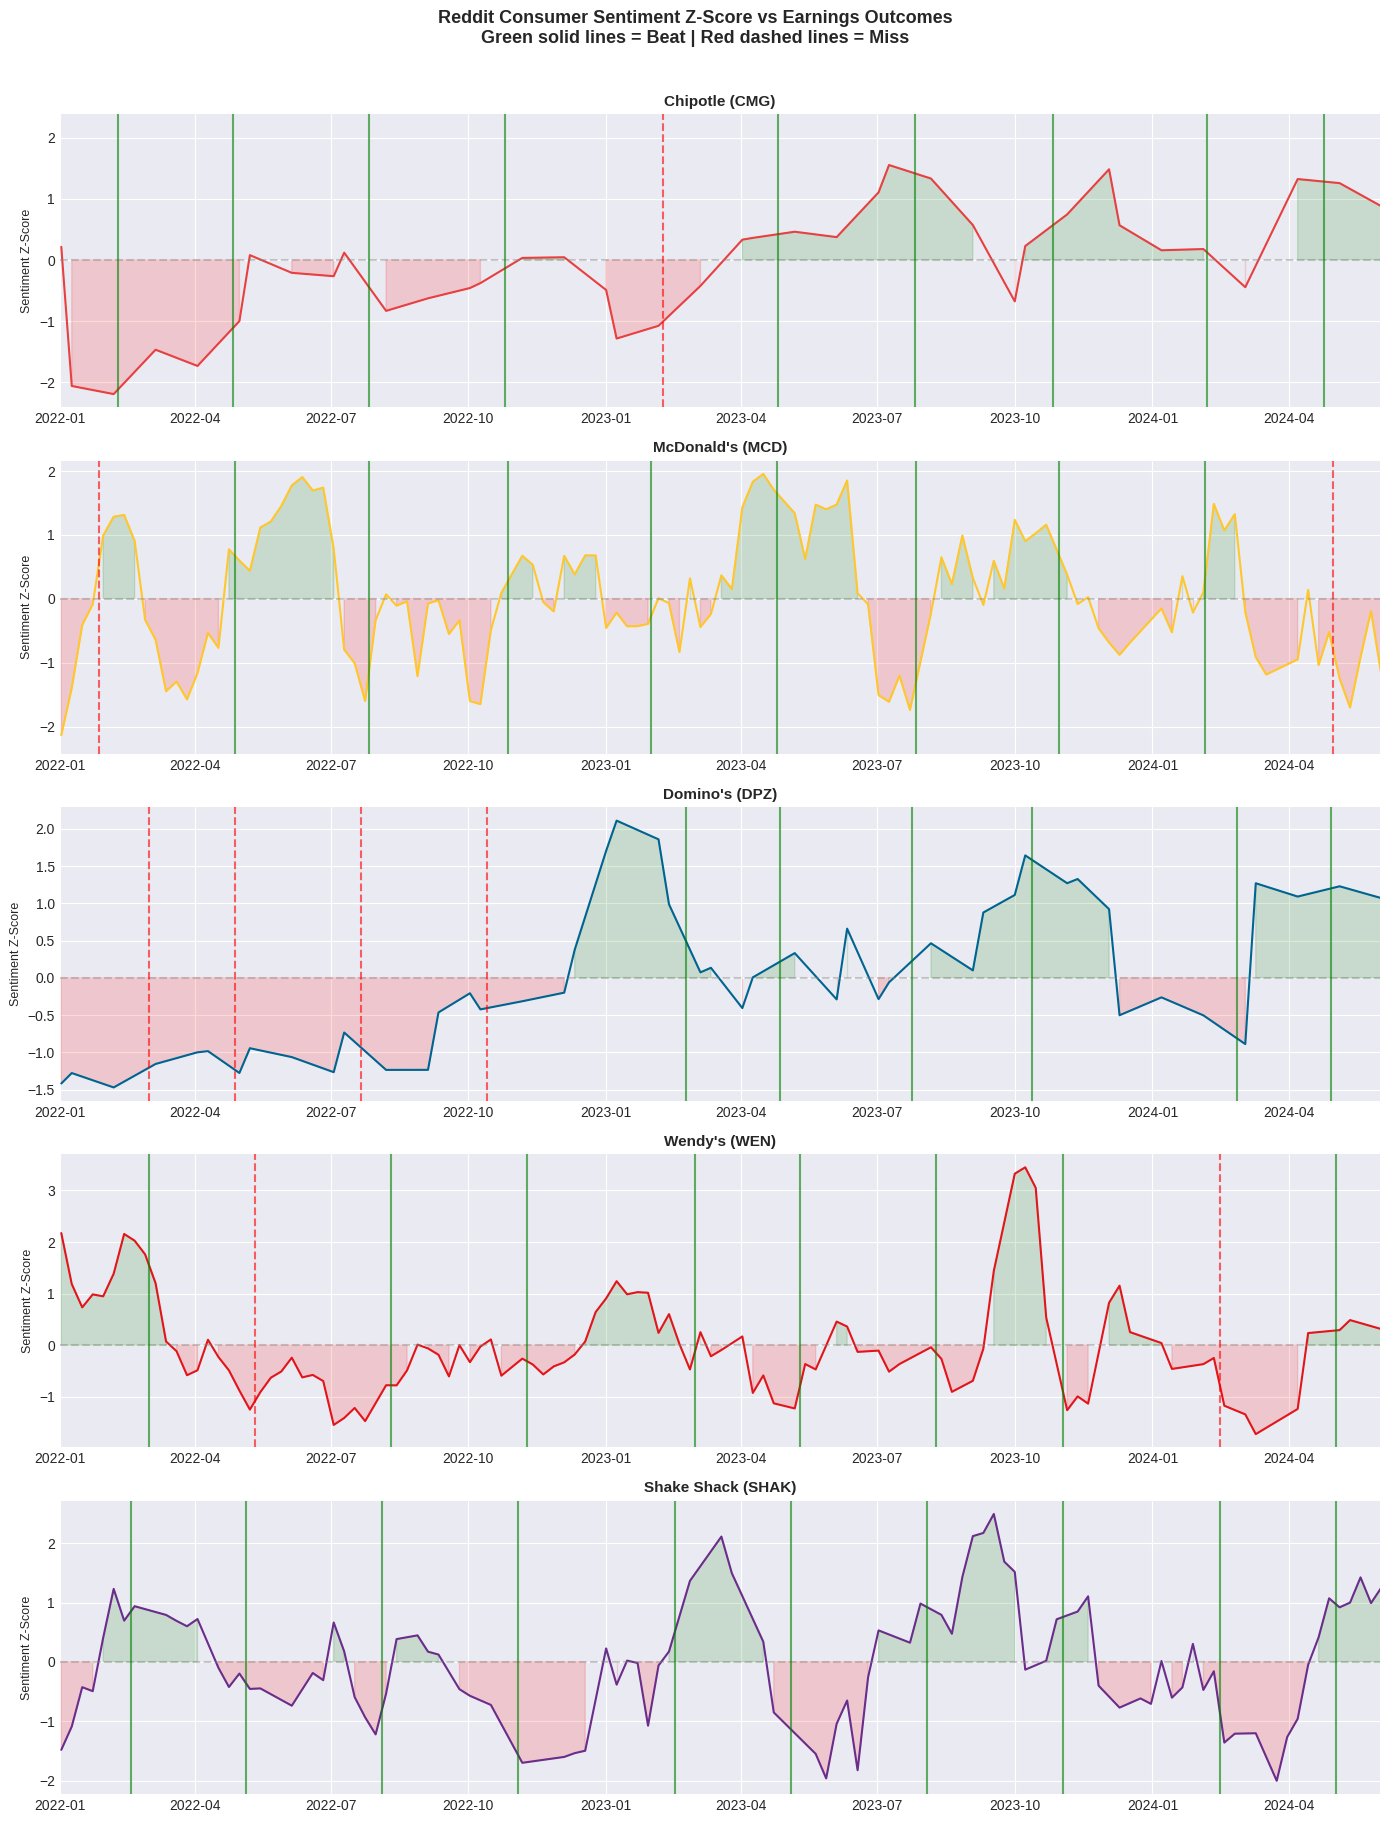

Chart 1 saved.


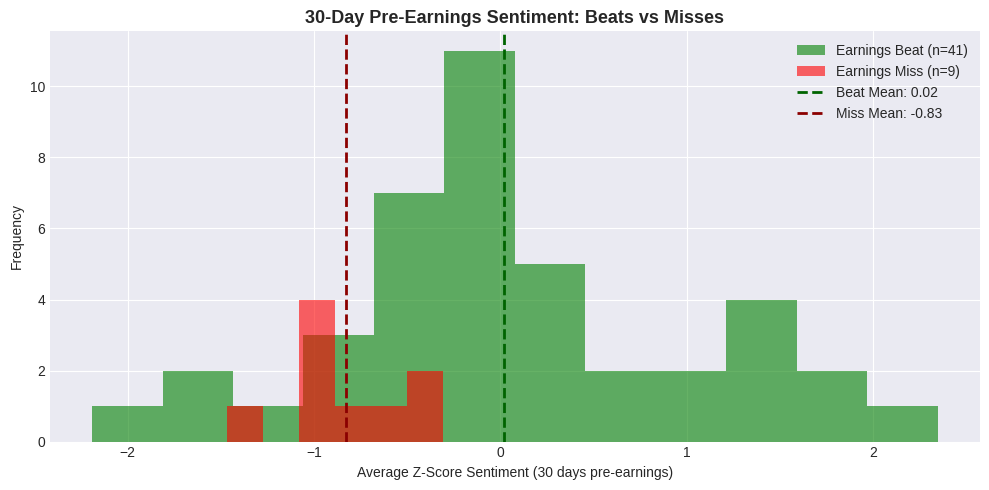

Chart 2 saved.


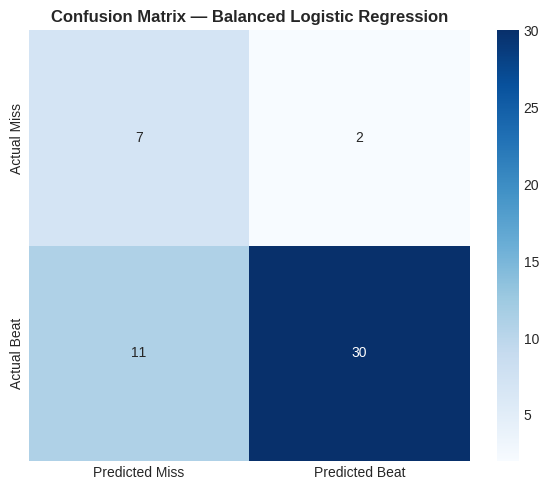

Chart 3 saved.


In [30]:
# ***DATA VISUALIZATIONS***

# Chart 1 — Sentiment z-score over time for each ticker. Shows how
# sentiment tracks against earnings outcomes.

plt.style.use('seaborn-v0_8-darkgrid')
ticker_names = {
    'CMG': 'Chipotle', 'MCD': "McDonald's",
    'DPZ': "Domino's", 'WEN': "Wendy's", 'SHAK': 'Shake Shack'
}
colors = {
    'CMG': '#E84040', 'MCD': '#FFC72C',
    'DPZ': '#006491', 'WEN': '#E2161A', 'SHAK': '#6B2D8B'
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, ticker in zip(axes, tickers):
    sent = weekly_sent[weekly_sent['ticker'] == ticker].copy()
    sent['date'] = pd.to_datetime(sent['date'])

    ax.plot(sent['date'], sent['sent_zscore'],
            color=colors[ticker], linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.fill_between(sent['date'], sent['sent_zscore'], 0,
                    where=sent['sent_zscore'] > 0,
                    alpha=0.15, color='green')
    ax.fill_between(sent['date'], sent['sent_zscore'], 0,
                    where=sent['sent_zscore'] < 0,
                    alpha=0.15, color='red')

    earn = model_df[model_df['ticker'] == ticker]
    for _, row in earn.iterrows():
        c = 'green' if row['beat'] == 1 else 'red'
        ax.axvline(pd.to_datetime(row['date']), color=c,
                  alpha=0.6, linewidth=1.5,
                  linestyle='-' if row['beat'] == 1 else '--')

    ax.set_title(f'{ticker_names[ticker]} ({ticker})',
                fontsize=11, fontweight='bold')
    ax.set_ylabel('Sentiment Z-Score', fontsize=9)
    ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-06-01'))

fig.suptitle(
    'Reddit Consumer Sentiment Z-Score vs Earnings Outcomes\n'
    'Green solid lines = Beat | Red dashed lines = Miss',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/content/chart1_sentiment_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

# Chart 2 — Distribution of Pre-Earnings Sentiment (beats vs misses)
fig, ax = plt.subplots(figsize=(10, 5))

beats = model_df[model_df['beat'] == 1]['pre_earn_sent']
misses = model_df[model_df['beat'] == 0]['pre_earn_sent']

ax.hist(beats, bins=12, alpha=0.6, color='green',
        label=f'Earnings Beat (n={len(beats)})')
ax.hist(misses, bins=6, alpha=0.6, color='red',
        label=f'Earnings Miss (n={len(misses)})')
ax.axvline(beats.mean(), color='darkgreen', linestyle='--',
          linewidth=2, label=f'Beat Mean: {beats.mean():.2f}')
ax.axvline(misses.mean(), color='darkred', linestyle='--',
          linewidth=2, label=f'Miss Mean: {misses.mean():.2f}')

ax.set_title('30-Day Pre-Earnings Sentiment: Beats vs Misses',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Average Z-Score Sentiment (30 days pre-earnings)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('/content/chart2_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

# Chart 3 — Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, model.predict(X))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Miss', 'Predicted Beat'],
            yticklabels=['Actual Miss', 'Actual Beat'], ax=ax)
ax.set_title('Confusion Matrix — Balanced Logistic Regression',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')